# Julia Set Preview
Before the profiling sections, render the Julia set once so you can see the target image.


build_Julia_set took 0.0851743221282959 seconds to execute.


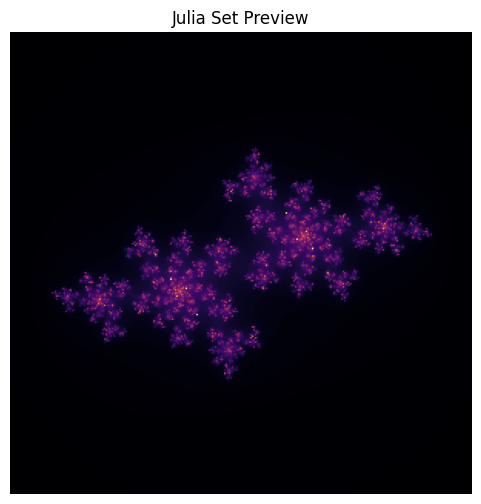

In [68]:
from importlib import reload
import matplotlib.pyplot as plt
import drawJulia

reload(drawJulia)

image, extent = drawJulia.build_julia_image(width=300, iterations=300)

plt.figure(figsize=(6, 6))
plt.imshow(image, extent=extent, cmap="inferno")
plt.title("Julia Set Preview")
plt.axis("off")
plt.show()


# PART1: Memory Profiling

### 1. Print
Measure execution time by printing directly inside `julia1.py`.

If you want to use the Unix `time` command in a terminal, the setup looks like this:

```bash
apt install time
vim ~/.bashrc
alias time='/usr/bin/time'
```

In a notebook, run Python code in a regular code cell instead of using terminal syntax.


In [ ]:
from importlib import reload
import time
import julia1

reload(julia1)

from julia1 import calculate_Julia_set, build_Julia_set

build_Julia_set(desired_width=1000, max_iterations=300)

zs = [complex(0.3, 0.5) for _ in range(100000)]
cs = [complex(-0.8, 0.156) for _ in range(100000)]
print("Total elements:", len(zs))

start_time = time.time()
output = calculate_Julia_set(300, zs, cs)
end_time = time.time()
secs = end_time - start_time
print(calculate_Julia_set.__name__ + " took", secs, "seconds")


### 2. Decorator
Use a wrapper function to measure execution time.
This avoids repeating manual `start_time` and `end_time` code in every function.

The decorator looks like this:


In [ ]:
from functools import wraps
import time

def timefn(fn):
    @wraps(fn)
    def measure_time(*args, **kwargs):
        t1 = time.time()
        result = fn(*args, **kwargs)
        t2 = time.time()
        print(f"@timefn: {fn.__name__} took {t2 - t1} seconds")
        return result
    return measure_time

In [ ]:
from julia1_decorator import timefnVer_build_Julia_set, timefnVer_calculate_Julia_set

output = timefnVer_build_Julia_set(desired_width=2000, max_iterations=500)


@timefn: timefnVer_calculate_Julia_set took 5.502036094665527 seconds
timefnVer_build_Julia_set took 5.502200126647949 seconds to execute.
@timefn: timefnVer_build_Julia_set took 7.093914747238159 seconds


### 3. `timeit` Module

Use `timeit` when you want repeated, more stable timing measurements.

Run this in a terminal:

```bash
python3 -m timeit -n 5 -r 1 -s "import julia1" "julia1.build_Julia_set(desired_width=1000, max_iterations=300)"
```

In Jupyter, use either `!python3 -m timeit ...` or the `%timeit` magic shown below.


In [ ]:
!python3 -m timeit -n 5 -r 1 -s "import julia1" "julia1.build_Julia_set(desired_width=1000, max_iterations=300)"


build_Julia_set took 1.2652475833892822 seconds to execute.
build_Julia_set took 1.1819629669189453 seconds to execute.
build_Julia_set took 1.2886126041412354 seconds to execute.
build_Julia_set took 1.197993278503418 seconds to execute.
build_Julia_set took 1.1520094871520996 seconds to execute.
5 loops, best of 1: 1.58 sec per loop


For the notebook environment, you can also use `%timeit`.
The results may differ slightly from terminal `timeit` because the execution environment is different.


In [ ]:
from importlib import reload
import julia1

reload(julia1)
from julia1 import build_Julia_set

%timeit build_Julia_set(desired_width=1000, max_iterations=300)


build_Julia_set took 1.1464338302612305 seconds to execute.
build_Julia_set took 1.0885579586029053 seconds to execute.
build_Julia_set took 1.138596773147583 seconds to execute.
build_Julia_set took 1.0905790328979492 seconds to execute.
build_Julia_set took 1.0415596961975098 seconds to execute.
build_Julia_set took 1.122577428817749 seconds to execute.
build_Julia_set took 1.0494351387023926 seconds to execute.
build_Julia_set took 1.051567554473877 seconds to execute.
1.4 s ± 26.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### 4. Unix `time` Command
This is a shell command, so it measures the whole program from outside Python.


In [ ]:
%%bash
time -p python3 julia1.py


build_Julia_set took 4.144006729125977 seconds to execute.


real 5.44
user 5.30
sys 0.13


### 5. `cProfile` Module
`cProfile` reports where the program spends its time.

Common columns include:

| Column | Meaning |
| --- | --- |
| `ncalls` | Number of function calls |
| `tottime` | Time spent in the function itself |
| `cumtime` | Total time including sub-function calls |
| `percall` | Average time per call |

This is usually run from a terminal or from a notebook shell command.


In [ ]:
%%bash
python3 -m cProfile -s cumulative julia1.py


build_Julia_set took 7.886834144592285 seconds to execute.
         33751014 function calls in 10.309 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   10.309   10.309 {built-in method builtins.exec}
        1    0.097    0.097   10.309   10.309 julia1.py:1(<module>)
        1    1.904    1.904   10.212   10.212 julia1.py:22(build_Julia_set)
        1    5.931    5.931    7.887    7.887 julia1.py:4(calculate_Julia_set)
 25747004    1.956    0.000    1.956    0.000 {built-in method builtins.abs}
  8004000    0.422    0.000    0.422    0.000 {method 'append' of 'list' objects}
        1    0.000    0.000    0.000    0.000 {built-in method builtins.print}
        2    0.000    0.000    0.000    0.000 {built-in method builtins.len}
        2    0.000    0.000    0.000    0.000 {built-in method time.time}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}


You can also save the profiling result to a file for later inspection:

```bash
python3 -m cProfile -o profile_julia1_run.stats julia1.py
```


### 6. `snakeviz` Module
`snakeviz` is a visualization tool for `cProfile` output.

Install it in a terminal if needed:

```bash
pip3 install snakeviz
```

Typical workflow:

```bash
python3 -m cProfile -o profile_julia1_run.stats julia1.py
snakeviz profile_julia1_run.stats
```

What you will see:

- `python3 -m cProfile -o profile_julia1_run.stats julia1.py` creates a stats file.
- `snakeviz profile_julia1_run.stats` opens an interactive visualization, usually in a browser.
- The main result is not plain notebook output; it is the browser-based profiling view.


In [ ]:
%%bash
python3 -m cProfile -o profile_julia1_run.stats julia1.py
ls -lh profile_julia1_run.stats


build_Julia_set took 7.692498207092285 seconds to execute.
-rw-rw-r-- 1 mhlee mhlee 1.1K Apr 17 16:45 profile_julia1_run.stats


In [ ]:
# Run this next command in a terminal, not in Jupyter:
# snakeviz profile_julia1_run.stats
# Result: interactive browser visualization


### 7. `line_profiler` Module
`line_profiler` measures execution time line by line.

Install it in a terminal if needed:

```bash
pip3 install line_profiler
```

To use it, add `@profile` above the function you want to inspect, then run:

```bash
kernprof -l -v line_profile_julia1.py
```


In [ ]:
%%bash
kernprof -l -v -o line_profile_julia1_run.lprof line_profile_julia1.py
ls -lh line_profile_julia1_run.lprof


Wrote profile results to 'line_profile_julia1_run.lprof'
Timer unit: 1e-06 s

Total time: 0 s
File: line_profile_julia1.py
Function: no_ABS_calculate_Julia_set at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           @profile
     2                                           def no_ABS_calculate_Julia_set(max_iter, zs, cs):
     3                                               output = [0] * len(zs)
     4                                           
     5                                               for i in range(len(zs)):
     6                                                   n = 0
     7                                                   z = zs[i]
     8                                                   c = cs[i]
     9                                           
    10                                                   while True:
    11                                           
    12                                 

### 8. `py-spy` Module
`py-spy` is a sampling profiler for running Python programs.
It can inspect a live process without modifying the source code.

Example terminal commands:

```bash
py-spy top --pid 12345
py-spy top -- python3 julia1.py
py-spy record -o profile.svg -- python3 julia1.py
```

What you will see:

- `py-spy top ...` shows live profiling information directly in the terminal.
- `py-spy record ...` creates a file such as `profile.svg`.
- The generated SVG can be opened later to inspect the profiling result visually.

Because `py-spy` works at the process level, it is best documented as a terminal workflow.


# Part2: Memory Profiling

### 1. memory_profiler module
This is similar to `cProfile`, but it reports memory usage instead of execution time.
Add `@profile` above the function you want to inspect, then run it with `memory_profiler`.


In [ ]:
%%bash
python3 -m memory_profiler memory_julia1.py


Filename: memory_julia1.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     3  122.582 MiB  122.582 MiB           1   @profile
     4                                         def calculate_Julia_set(max_iter, zs, cs):
     5  130.215 MiB    7.633 MiB           1       output = [0] * len(zs)
     6  130.215 MiB    0.000 MiB      487641       for i in range(len(zs)):
     7  130.215 MiB    0.000 MiB      487641         n = 0
     8  130.215 MiB    0.000 MiB      487641         z = zs[i]
     9  130.215 MiB    0.000 MiB      487641         c = cs[i]
    10  130.215 MiB    0.000 MiB     3021780         while abs(z) < 2 and n < max_iter:
    11  130.215 MiB    0.000 MiB     2534140           z = z * z + c
    12  130.215 MiB    0.000 MiB     2534140           n += 1
    13  130.215 MiB    0.000 MiB      487640         output[i] = n
    14                                             return output


Filename: memory_julia1.py

Line #    Mem usage    Increment  Occurrences   

Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/psutil/_common.py", line 441, in wrapper
    ret = self._cache[fun]
AttributeError: 'Process' object has no attribute '_cache'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/memory_profiler.py", line 1351, in <module>
    exec_with_profiler(script_filename, prof, args.backend, script_args)
  File "/usr/local/lib/python3.10/dist-packages/memory_profiler.py", line 1252, in exec_with_profiler
    exec(compile(f.read(), filename, 'exec'), ns, ns)
  File "memory_julia1.py", line 59, in <module>
    build_Julia_set(1000, 300)
  File "/usr/local/lib/python3.10/dist-packages/memory_profiler.py", line 761, in f
  

Error while terminating subprocess (pid=80268): 


TypeError: %d format: a real number is required, not NoneType

### 2. mprof module
This module shows how memory usage changes over time.
If the change is too fast to notice, adding `time.sleep(1)` can exaggerate the effect and make the graph easier to read.


In [ ]:
%%bash
mprof run memory_julia1.py
mprof plot -o mprof_memory_julia1.png
ls -lh mprof_memory_julia1.png


Result for the command above:

![mprof result for memory_julia1](mprof_memory_julia1.png)


In [ ]:
%%bash
mprof run memory_julia1_sleep.py
mprof plot -o mprof_memory_julia1_sleep.png
ls -lh mprof_memory_julia1_sleep.png


Result for the command above:

![mprof result for memory_julia1_sleep](mprof_memory_julia1_sleep.png)


### 3. `%memit` and `--pdb-mmem`
`%memit` is useful inside Jupyter when you want a quick memory measurement for one statement.
The `--pdb-mmem` option is useful from the terminal when you want `memory_profiler` to stop after memory usage crosses a threshold.


In [ ]:
%load_ext memory_profiler
from julia1 import build_Julia_set
%memit build_Julia_set(desired_width=1000, max_iterations=300)


In [ ]:
%%bash
# Example terminal command:
python3 -m memory_profiler --pdb-mmem=100 memory_julia1.py


### 4. `dis` Module
The `dis` module shows Python bytecode for a function.
This is helpful when you want to inspect what Python executes internally.

Common columns include:

| Column | Meaning |
| --- | --- |
| instruction offset | Position of the bytecode instruction |
| opcode name | The operation name, such as `LOAD_FAST` or `CALL` |
| argument | Numeric argument for the opcode, if present |
| argument meaning | Human-readable interpretation of the argument |


In [ ]:
import dis
import memory_julia1

dis.dis(memory_julia1.build_Julia_set)
